# Лабораторная работа №2

## Тема: Расширенный статистический анализ и методы машинного обучения на данных о Нобелевских лауреатах

**Источник данных:** `laureates.json` из [API Nobel Prize](`https://api.nobelprize.org/2.1/laureates`).

**Объем данных:** 1018 лауреатов и 1026 присужденных премий.

**Авторы:** Григорий Зайка, Артур Мамалига, Анатолий Курилов.

**Группа:** I2302.

Целью данной работы является выявление статистических закономерностей и зависимостей в данных о Нобелевских лауреатах, а также моделирование взаимосвязей между датой рождения лауреата, годом присуждения премии и суммой премии. Для этого применяются методы разведочного и инференциального статистического анализа, а также алгоритмы машинного обучения (регрессия, классификация, PCA и временные модели), позволяющие формализовать влияние факторов, проверять гипотезы и осуществлять прогнозирование характеристик присуждения премий.

### Структура работы

1. Введение и описание данных.
2. Предобработка, очистка и построение признаков.
3. Разведочный анализ данных и визуализации.
4. Регрессионная и классификационная модели.
5. PCA и анализ временного ряда.
6. Интерпретация результатов, ограничения и рекомендации.
7. Библиография и вклад участников.

### Распределение ролей

- Григорий Зайка - постановка задачи, сбор данных и предобработка.
- Артур Мамалига - EDA и визуализация.
- Анатолий Курилов - модели регрессии, классификации, PCA и ARIMA.

### Почему выбран именно этот набор данных

Данные о Нобелевских лауреатах подходят для полной аналитической цепочки: в них есть категориальные и числовые признаки, временная составляющая по годам премий, пропуски, выбросы, а также естественные задачи для регрессии, классификации, снижения размерности и анализа временного ряда.

### Структура данных из CSV (`laureates.json`)

Ниже приведена структура основной аналитической таблицы, с которой выполняется большая часть анализа.

| Поле                            | Тип данных   | Понятное объяснение                                                                                                                 |
| ------------------------------- | ------------ | ----------------------------------------------------------------------------------------------------------------------------------- |
| **laureate_id**                 | строка/число | Уникальный номер лауреата в базе данных.                                           |
| **file_name**                   | строка       | Имя записи в файле или источнике данных.                            |
| **gender**                      | строка       | Пол человека                                                                           |
| **known_name**                  | строка       | Имя, под которым человек наиболее известен                                                  |
| **full_name**                   | строка       | Полное официальное имя человека                                                                      |
| **birth_date**                  | строка       | Дата рождения в полном формате (день, месяц, год), например: 12-03-1950.                                                            |
| **birth_year**                  | число        | Год рождения (например: 1950).                                                        |
| **birth_country**               | строка       | Страна человека на момент его рождения (может быть исторической, например СССР).                                  |
| **birth_country_now**           | строка       | Та же территория, но уже в современных границах (например: Россия вместо СССР).                                                     |
| **birth_continent**             | строка       | Континент, на котором родился человек (Европа, Азия и т.д.).                                                                        |
| **birth_location**              | строка       | Полное место рождения одной строкой (город + страна).                                                                        |
| **death_year**                  | число        | Год смерти человека (если он умер)                                                      |
| **prize_count**                 | число        | Сколько раз человек получал Нобелевскую премию                                                            |
| **first_award_year**            | число        | Год, когда человек впервые получил Нобелевскую премию.                                                                              |
| **first_category**              | строка       | Категория первой премии (например: Physics - физика, Chemistry - химия, Peace - мир и т.д.).                                        |
| **first_prize_amount_adjusted** | число        | Денежная сумма первой премии в долларах, пересчитанная с учётом инфляции |
| **first_motivation**            | строка       | Официальная формулировка, за что именно была присуждена премия (текстовое описание причины).                                        |
| **first_affiliation_name**      | строка       | Название организации, в которой работал лауреат на момент получения премии                     |
| **first_affiliation_city**      | строка       | Город, где находится эта организация.                                                                                               |
| **first_award_country**         | строка       | Страна, с которой связан лауреат на момент получения премии (обычно страна его организации).                                        |
| **first_award_continent**       | строка       | Континент этой страны (например: Европа, Северная Америка).                                                                         |
| **is_science**                  | 0/1          | Показывает, относится ли премия к науке: 1 - да (физика, химия, медицина), 0 - нет (литература, мир, экономика).                    |


Дополнительно в ноутбуке используется `nobel_prizes_long.csv` - длинная таблица по всем премиям, где одна строка соответствует одной награде.

In [22]:
from pathlib import Path
import json
import subprocess
import sys
import warnings

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "pandas",
        "numpy",
        "matplotlib",
        "seaborn",
        "scikit-learn",
        "statsmodels",
    ]
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

DATA_PATH = Path("laureates.json")
SCIENTIFIC_CATEGORIES = {
    "Physics",
    "Chemistry",
    "Physiology or Medicine",
    "Economic Sciences",
}

with DATA_PATH.open(encoding="utf-8") as handle:
    raw_data = json.load(handle)


def first_item(value):
    if isinstance(value, list) and value:
        return value[0]
    return {}


def nested_value(mapping, *keys):
    current = mapping
    for key in keys:
        if not isinstance(current, dict):
            return None
        current = current.get(key)
    return current


laureate_records = []
prize_records = []

for source_row in raw_data["laureates"]:
    laureate_id = source_row.get("id")
    file_name = source_row.get("fileName")
    gender = source_row.get("gender")
    known_name = nested_value(source_row, "knownName", "en")
    full_name = nested_value(source_row, "fullName", "en")
    birth_date = nested_value(source_row, "birth", "date")
    birth_year = pd.to_numeric(nested_value(source_row, "birth", "year"), errors="coerce")
    birth_country = nested_value(source_row, "birth", "place", "country", "en")
    birth_country_now = nested_value(source_row, "birth", "place", "countryNow", "en")
    birth_continent = nested_value(source_row, "birth", "place", "continent", "en")
    birth_location = nested_value(source_row, "birth", "place", "locationString", "en")
    death_date = nested_value(source_row, "death", "date")
    death_year = pd.to_numeric(str(death_date).split("-")[0], errors="coerce") if death_date else np.nan
    prizes = source_row.get("nobelPrizes", []) or []
    prize_count = len(prizes)
    first_prize = prizes[0] if prizes else {}
    first_award_year = pd.to_numeric(first_prize.get("awardYear"), errors="coerce")
    first_category = nested_value(first_prize, "category", "en")
    first_prize_amount = pd.to_numeric(first_prize.get("prizeAmountAdjusted"), errors="coerce")
    first_motivation = nested_value(first_prize, "motivation", "en")
    first_affiliation = first_item(first_prize.get("affiliations"))
    first_residence = first_item(first_prize.get("residences"))
    first_award_country = (
        nested_value(first_affiliation, "countryNow", "en")
        or nested_value(first_affiliation, "country", "en")
        or nested_value(first_residence, "countryNow", "en")
        or nested_value(first_residence, "country", "en")
    )
    first_award_continent = nested_value(first_affiliation, "continent", "en") or nested_value(first_residence, "continent", "en")
    first_affiliation_name = nested_value(first_affiliation, "name", "en")
    first_affiliation_city = nested_value(first_affiliation, "cityNow", "en") or nested_value(first_affiliation, "city", "en")
    first_is_science = int(first_category in SCIENTIFIC_CATEGORIES) if pd.notna(first_category) else np.nan

    laureate_records.append(
        {
            "laureate_id": laureate_id,
            "file_name": file_name,
            "gender": gender,
            "known_name": known_name,
            "full_name": full_name,
            "birth_date": birth_date,
            "birth_year": birth_year,
            "birth_country": birth_country,
            "birth_country_now": birth_country_now,
            "birth_continent": birth_continent,
            "birth_location": birth_location,
            "death_year": death_year,
            "prize_count": prize_count,
            "first_award_year": first_award_year,
            "first_category": first_category,
            "first_prize_amount_adjusted": first_prize_amount,
            "first_motivation": first_motivation,
            "first_affiliation_name": first_affiliation_name,
            "first_affiliation_city": first_affiliation_city,
            "first_award_country": first_award_country,
            "first_award_continent": first_award_continent,
            "is_science": first_is_science,
        }
    )

    for prize_index, prize in enumerate(prizes, start=1):
        award_year = pd.to_numeric(prize.get("awardYear"), errors="coerce")
        category = nested_value(prize, "category", "en")
        prize_amount = pd.to_numeric(prize.get("prizeAmountAdjusted"), errors="coerce")
        motivation = nested_value(prize, "motivation", "en")
        affiliation = first_item(prize.get("affiliations"))
        residence = first_item(prize.get("residences"))
        award_country = (
            nested_value(affiliation, "countryNow", "en")
            or nested_value(affiliation, "country", "en")
            or nested_value(residence, "countryNow", "en")
            or nested_value(residence, "country", "en")
        )
        award_continent = nested_value(affiliation, "continent", "en") or nested_value(residence, "continent", "en")
        prize_records.append(
            {
                "laureate_id": laureate_id,
                "file_name": file_name,
                "gender": gender,
                "known_name": known_name,
                "full_name": full_name,
                "birth_year": birth_year,
                "award_year": award_year,
                "category": category,
                "prize_amount_adjusted": prize_amount,
                "motivation": motivation,
                "affiliation_name": nested_value(affiliation, "name", "en"),
                "affiliation_city": nested_value(affiliation, "cityNow", "en") or nested_value(affiliation, "city", "en"),
                "award_country": award_country,
                "award_continent": award_continent,
                "prize_index": prize_index,
                "is_science": int(category in SCIENTIFIC_CATEGORIES) if pd.notna(category) else np.nan,
            }
        )

laureate_df = pd.DataFrame(laureate_records)
prize_df = pd.DataFrame(prize_records)

laureate_df.to_csv("nobel_laureates.csv", index=False, encoding="utf-8")
prize_df.to_csv("nobel_prizes_long.csv", index=False, encoding="utf-8")

category_ru = {
    "Physics": "Физика",
    "Chemistry": "Химия",
    "Physiology or Medicine": "Физиология или медицина",
    "Peace": "Премия мира",
    "Literature": "Литература",
    "Economic Sciences": "Экономические науки",
}
gender_ru = {"male": "Мужчины", "female": "Женщины"}
continent_ru = {
    "Europe": "Европа",
    "Asia": "Азия",
    "North America": "Северная Америка",
    "South America": "Южная Америка",
    "Africa": "Африка",
    "Oceania": "Океания",
    "Unknown": "Неизвестно",
}
country_ru = {
    "USA": "США",
    "United Kingdom": "Великобритания",
    "Germany": "Германия",
    "France": "Франция",
    "Sweden": "Швеция",
    "Switzerland": "Швейцария",
    "Japan": "Япония",
    "Russia": "Россия",
    "Italy": "Италия",
    "Unknown": "Неизвестно",
}

preview_df = laureate_df.head(3).rename(columns={
    "laureate_id": "ID лауреата",
    "file_name": "Служебное имя записи",
    "gender": "Пол",
    "known_name": "Известное имя",
    "full_name": "Полное имя",
    "birth_date": "Дата рождения",
    "birth_year": "Год рождения",
    "birth_country": "Страна рождения (историческая)",
    "birth_country_now": "Страна рождения (современная)",
    "birth_continent": "Континент рождения",
    "birth_location": "Место рождения (полное)",
    "death_year": "Год смерти",
    "prize_count": "Количество премий",
    "first_award_year": "Год первой премии",
    "first_category": "Категория первой премии",
    "first_prize_amount_adjusted": "Сумма премии (USD, с учетом инфляции)",
    "first_motivation": "Причина награждения",
    "first_affiliation_name": "Организация лауреата",
    "first_affiliation_city": "Город организации",
    "first_award_country": "Страна организации (при награждении)",
    "first_award_continent": "Континент организации",
    "is_science": "Научная категория (1/0)",
})

preview_df["Пол"] = preview_df["Пол"].map(gender_ru)
preview_df["Категория первой премии"] = preview_df["Категория первой премии"].map(category_ru)
preview_df["Континент рождения"] = preview_df["Континент рождения"].map(continent_ru)
preview_df["Континент организации"] = preview_df["Континент организации"].map(continent_ru)

preview_df["Страна рождения (историческая)"] = preview_df["Страна рождения (историческая)"].map(country_ru).fillna(
    preview_df["Страна рождения (историческая)"]
)
preview_df["Страна рождения (современная)"] = preview_df["Страна рождения (современная)"].map(country_ru).fillna(
    preview_df["Страна рождения (современная)"]
)
preview_df["Страна организации (при награждении)"] = preview_df["Страна организации (при награждении)"].map(country_ru).fillna(
    preview_df["Страна организации (при награждении)"]
)

preview_df["Научная категория (1/0)"] = preview_df["Научная категория (1/0)"].map({1: "Да", 0: "Нет"})

print(f"Таблица лауреатов: {laureate_df.shape[0]} строк x {laureate_df.shape[1]} столбцов")
print(f"Таблица премий: {prize_df.shape[0]} строк x {prize_df.shape[1]} столбцов")
display(preview_df)

Таблица лауреатов: 1018 строк x 22 столбцов
Таблица премий: 1026 строк x 16 столбцов


,ID лауреата,Служебное имя записи,Пол,Известное имя,Полное имя,Дата рождения,Год рождения,Страна рождения (историческая),Страна рождения (современная),Континент рождения,Место рождения (полное),Год смерти,Количество премий,Год первой премии,Категория первой премии,"Сумма премии (USD, с учетом инфляции)",Причина награждения,Организация лауреата,Город организации,Страна организации (при награждении),Континент организации,Научная категория (1/0)
0,745,spence,Мужчины,A. Michael Spence,A. Michael Spence,1943-00-00,1943.0,США,США,Северная Америка,"Montclair, NJ, USA",NaN,1,2001,Экономические науки,15547541,for their analyses of markets with asymmetric ...,Stanford University,"Stanford, CA",США,Северная Америка,Да
1,102,bohr,Мужчины,Aage N. Bohr,Aage Niels Bohr,1922-06-19,1922.0,Denmark,Denmark,Европа,"Copenhagen, Denmark",2009.0,1,1975,Физика,4304697,for the discovery of the connection between co...,Niels Bohr Institute,Copenhagen,Denmark,Европа,Да
2,779,ciechanover,Мужчины,Aaron Ciechanover,Aaron Ciechanover,1947-10-01,1947.0,British Protectorate of Palestine,Israel,Азия,"Haifa, British Protectorate of Palestine (now ...",NaN,1,2004,Химия,14874529,for the discovery of ubiquitin-mediated protei...,Technion - Israel Institute of Technology,Haifa,Israel,Азия,Да


In [23]:
analysis_df = laureate_df.copy()
analysis_df["award_year_num"] = pd.to_numeric(analysis_df["first_award_year"], errors="coerce")
analysis_df["birth_year"] = pd.to_numeric(analysis_df["birth_year"], errors="coerce")
analysis_df["age_awarded"] = analysis_df["award_year_num"] - analysis_df["birth_year"]
analysis_df["prize_amount_log"] = np.log1p(analysis_df["first_prize_amount_adjusted"])
analysis_df["award_decade"] = (analysis_df["award_year_num"] // 10) * 10
analysis_df["continent_group"] = analysis_df["first_award_continent"].fillna(analysis_df["birth_continent"]).fillna("Неизвестно")
analysis_df["primary_country"] = (
    analysis_df["first_award_country"]
    .fillna(analysis_df["birth_country_now"])
    .fillna(analysis_df["birth_country"])
    .fillna("Неизвестно")
)
analysis_df["age_awarded_clipped"] = analysis_df["age_awarded"].clip(
    lower=analysis_df["age_awarded"].quantile(0.01),
    upper=analysis_df["age_awarded"].quantile(0.99),
)
analysis_df["primary_gender_code"] = analysis_df["gender"].map({"male": 0, "female": 1})
analysis_df["is_science"] = analysis_df["is_science"].fillna(0).astype(int)

print(f"Сводка по качеству данных для {len(analysis_df)} лауреатов")
missing_summary = analysis_df.isna().mean().sort_values(ascending=False)
missing_summary = missing_summary.head(12).rename(index={
    "death_year": "Год смерти",
    "first_affiliation_city": "Город первой аффилиации",
    "first_affiliation_name": "Название первой аффилиации",
    "first_award_continent": "Континент первой премии",
    "first_award_country": "Страна первой премии",
    "birth_country": "Страна рождения",
    "birth_country_now": "Страна рождения (совр.)",
    "birth_continent": "Континент рождения",
    "birth_location": "Место рождения",
    "full_name": "Полное имя",
    "gender": "Пол",
    "birth_year": "Год рождения",
}).to_frame(name="Доля пропусков")
display(missing_summary)
print("\nСводка возраста на момент награждения:")
display(analysis_df["age_awarded"].describe().rename(index={
    "count": "Количество",
    "mean": "Среднее",
    "std": "Стандартное отклонение",
    "min": "Минимум",
    "25%": "Q1",
    "50%": "Медиана",
    "75%": "Q3",
    "max": "Максимум",
}))
print("\nСводка суммы премии в логарифмической шкале:")
display(analysis_df["prize_amount_log"].describe().rename(index={
    "count": "Количество",
    "mean": "Среднее",
    "std": "Стандартное отклонение",
    "min": "Минимум",
    "25%": "Q1",
    "50%": "Медиана",
    "75%": "Q3",
    "max": "Максимум",
}))
print("\nПроверка выбросов по возрасту методом IQR:")
q1 = analysis_df["age_awarded"].quantile(0.25)
q3 = analysis_df["age_awarded"].quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
outlier_mask = analysis_df["age_awarded"].between(lower_fence, upper_fence, inclusive="both")
outlier_count = outlier_mask.value_counts(dropna=False).rename(index={True: "В пределах нормы", False: "Выбросы"})
display(outlier_count.to_frame(name="Количество"))
print("\nПервые наблюдения по ключевым признакам:")
display(analysis_df[["first_category", "gender", "continent_group"]].head(8).rename(columns={
    "first_category": "Категория",
    "gender": "Пол",
    "continent_group": "Континент",
}))

Сводка по качеству данных для 1018 лауреатов


,Доля пропусков
Год смерти,0.321218
Город первой аффилиации,0.265226
Название первой аффилиации,0.260314
Континент первой премии,0.042240
Страна первой премии,0.041257
Страна рождения,0.030452
Страна рождения (совр.),0.030452
Континент рождения,0.030452
Место рождения,0.030452
Полное имя,0.027505



Сводка возраста на момент награждения:


Количество                990.000000
Среднее                    60.441414
Стандартное отклонение     12.675546
Минимум                    17.000000
Q1                         52.000000
Медиана                    61.000000
Q3                         70.000000
Максимум                   97.000000
Name: age_awarded, dtype: float64


Сводка суммы премии в логарифмической шкале:


Количество                1018.000000
Среднее                     15.758365
Стандартное отклонение       0.552171
Минимум                     14.916166
Q1                          15.182428
Медиана                     15.739035
Q3                          16.266825
Максимум                    16.559413
Name: prize_amount_log, dtype: float64


Проверка выбросов по возрасту методом IQR:


,Количество
age_awarded,
В пределах нормы,989
Выбросы,29



Первые наблюдения по ключевым признакам:


,Категория,Пол,Континент
0,Economic Sciences,male,North America
1,Physics,male,Europe
2,Chemistry,male,Asia
3,Chemistry,male,Europe
4,Literature,male,Неизвестно
5,Physics,male,Europe
6,Economic Sciences,male,North America
7,Peace,male,Africa


### III. Разведочный анализ данных (EDA)

На этом этапе исследуем структуру данных, распределения ключевых признаков и связи между ними.

Основные вопросы:

- какие категории и страны встречаются чаще всего;
- как менялось количество Нобелевских премий по годам;
- есть ли различия в возрасте лауреатов по категориям;
- какие числовые признаки связаны между собой сильнее всего.

Описательная статистика по ключевым признакам


,birth_year,first_award_year,age_awarded,first_prize_amount_adjusted,prize_count
Количество,990.000000,1018.000000,990.000000,1.018000e+03,1018.000000
Среднее,1914.412121,1975.072692,60.441414,8.064620e+06,1.007859
Стандартное отклонение,32.721762,35.036891,12.675546,4.104849e+06,0.098848
Минимум,1817.000000,1901.000000,17.000000,3.006134e+06,1.000000
Q1,1895.000000,1950.000000,52.000000,3.923237e+06,1.000000
Медиана,1919.500000,1980.000000,61.000000,6.845037e+06,1.000000
Q3,1940.000000,2004.750000,70.000000,1.160359e+07,1.000000
Максимум,1997.000000,2025.000000,97.000000,1.554754e+07,3.000000



Топ категорий


,Количество
category,
Физиология или медицина,232
Физика,230
Химия,200
Премия мира,143
Литература,122
Экономические науки,99



Топ стран


,Количество
primary_country,
США,431
Великобритания,118
Германия,85
Франция,64
Швеция,32
Швейцария,30
Неизвестно,27
Япония,24
Россия,19



Распределение по полу


,Количество
gender,
Мужчины,923
Женщины,67


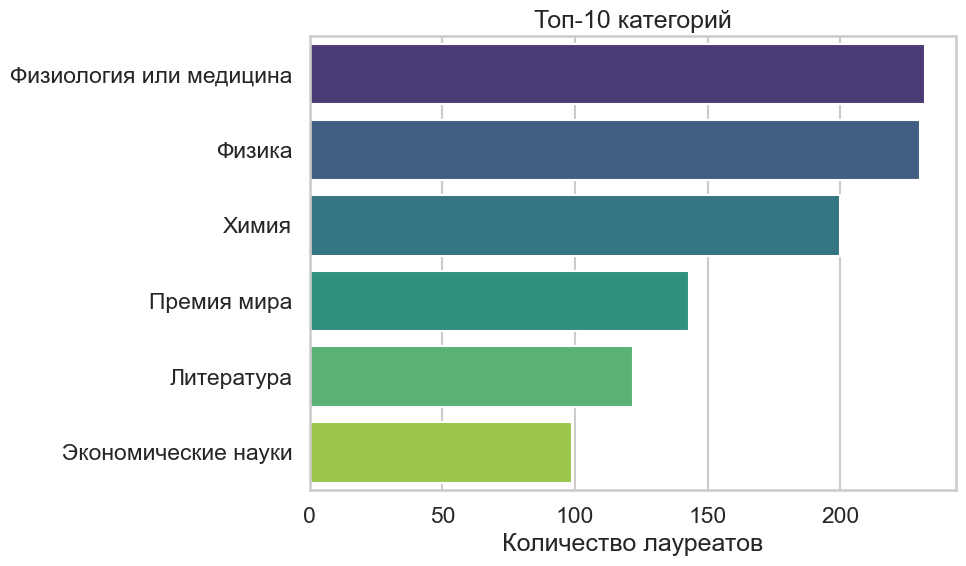

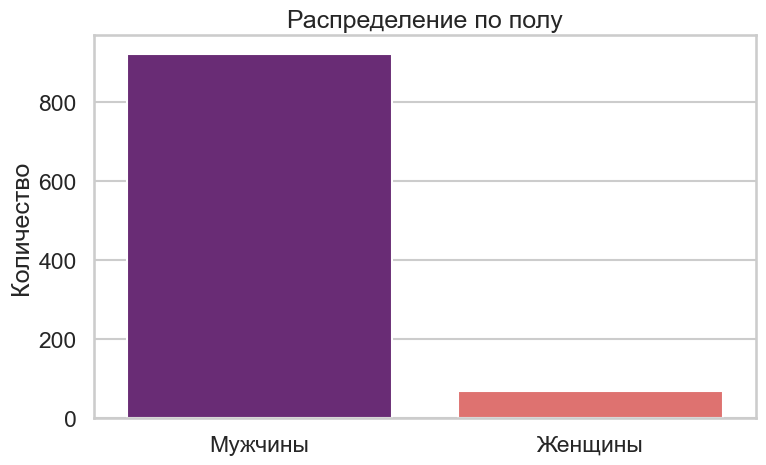

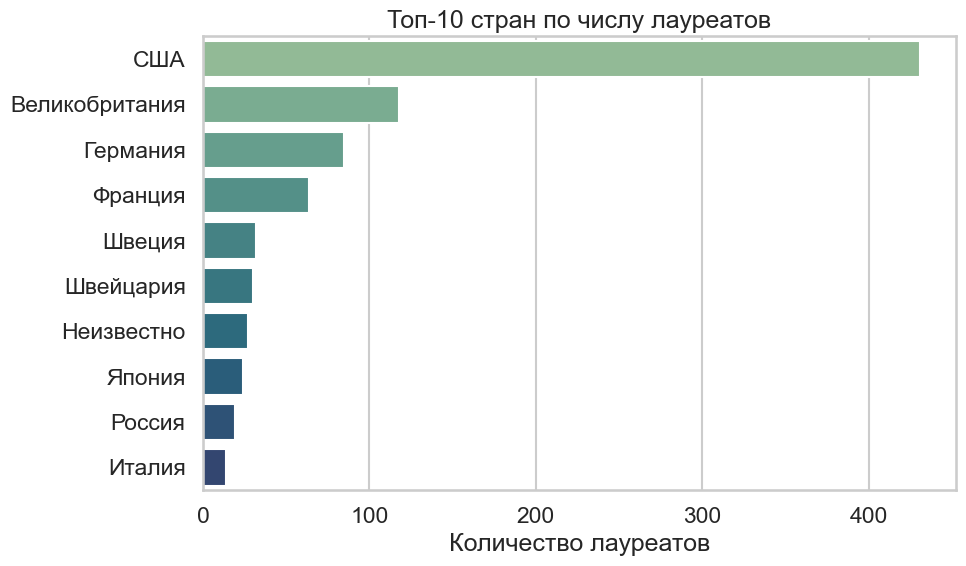

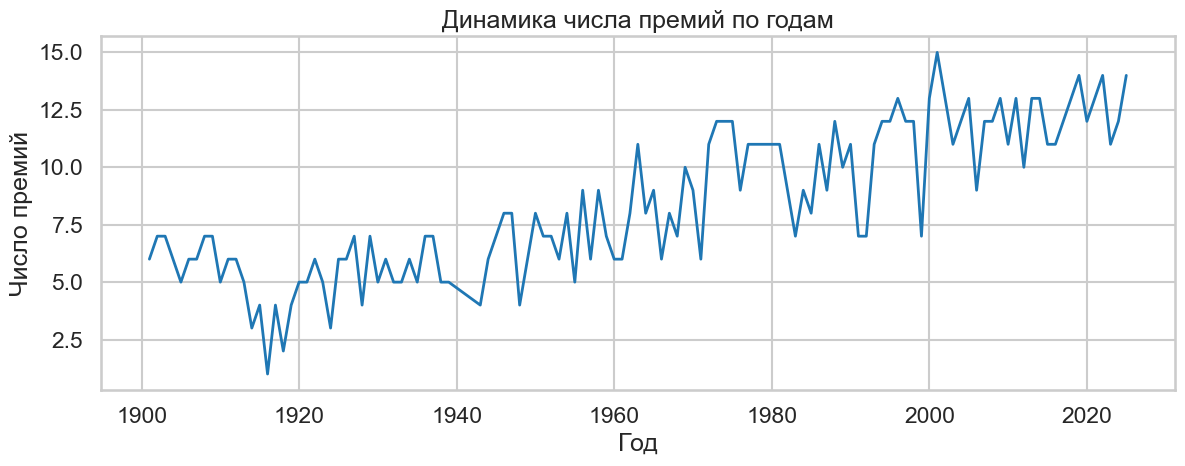

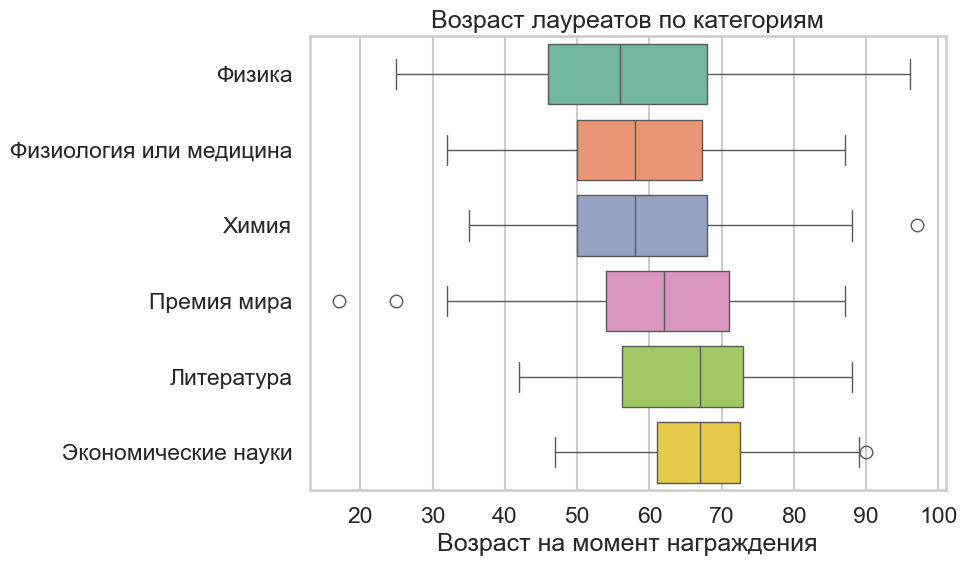

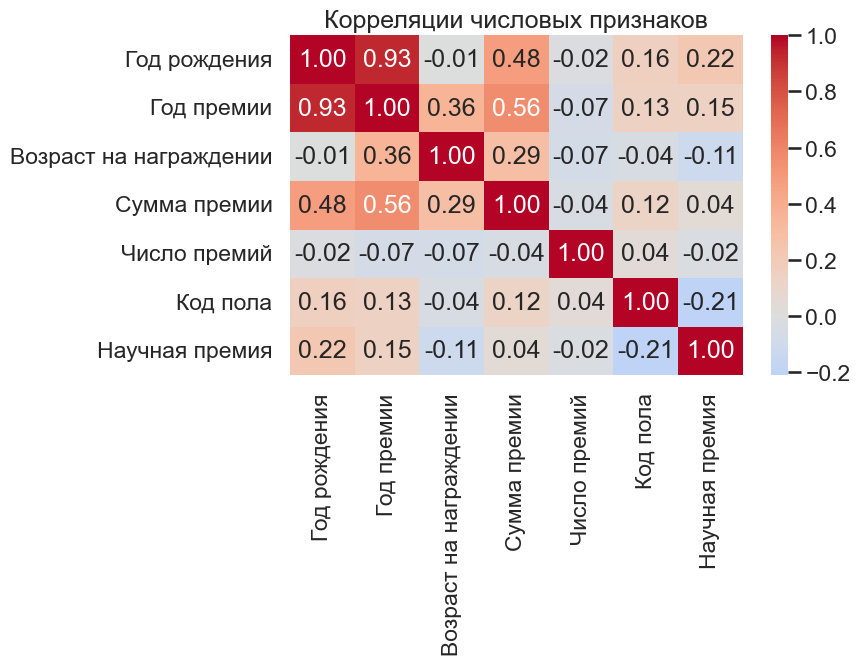

In [24]:
prize_eda = prize_df.copy()
prize_eda["award_year"] = pd.to_numeric(prize_eda["award_year"], errors="coerce")
prize_eda["primary_country"] = prize_eda["award_country"].fillna("Неизвестно")

category_ru = {
    "Physics": "Физика",
    "Chemistry": "Химия",
    "Physiology or Medicine": "Физиология или медицина",
    "Peace": "Премия мира",
    "Literature": "Литература",
    "Economic Sciences": "Экономические науки",
}

gender_ru = {"male": "Мужчины", "female": "Женщины"}
country_ru = {
    "USA": "США",
    "United Kingdom": "Великобритания",
    "Germany": "Германия",
    "France": "Франция",
    "Sweden": "Швеция",
    "Switzerland": "Швейцария",
    "Japan": "Япония",
    "Russia": "Россия",
    "Italy": "Италия",
    "Неизвестно": "Неизвестно",
}

print("Описательная статистика по ключевым признакам")
display(analysis_df[["birth_year", "first_award_year", "age_awarded", "first_prize_amount_adjusted", "prize_count"]].describe().rename(index={
    "count": "Количество",
    "mean": "Среднее",
    "std": "Стандартное отклонение",
    "min": "Минимум",
    "25%": "Q1",
    "50%": "Медиана",
    "75%": "Q3",
    "max": "Максимум",
}))

print("\nТоп категорий")
top_category_counts = prize_eda["category"].value_counts().head(10).rename(index=category_ru)
display(top_category_counts.to_frame(name="Количество"))

print("\nТоп стран")
top_country_counts = analysis_df["primary_country"].value_counts().head(10).rename(index=country_ru)
display(top_country_counts.to_frame(name="Количество"))

print("\nРаспределение по полу")
display(analysis_df["gender"].value_counts().rename(index=gender_ru).to_frame(name="Количество"))

yearly_counts = prize_eda.groupby("award_year").size().sort_index()
box_categories = analysis_df["first_category"].value_counts().head(8).index.tolist()
box_df = analysis_df[analysis_df["first_category"].isin(box_categories)].copy()
box_df["category_ru"] = box_df["first_category"].map(category_ru)
box_order = box_df.groupby("category_ru")["age_awarded"].median().sort_values().index.tolist()

corr_columns = [
    "birth_year",
    "first_award_year",
    "age_awarded",
    "first_prize_amount_adjusted",
    "prize_count",
    "primary_gender_code",
    "is_science",
]
corr_matrix = analysis_df[corr_columns].corr(numeric_only=True)
corr_matrix = corr_matrix.rename(index={
    "birth_year": "Год рождения",
    "first_award_year": "Год премии",
    "age_awarded": "Возраст на награждении",
    "first_prize_amount_adjusted": "Сумма премии",
    "prize_count": "Число премий",
    "primary_gender_code": "Код пола",
    "is_science": "Научная премия",
}, columns={
    "birth_year": "Год рождения",
    "first_award_year": "Год премии",
    "age_awarded": "Возраст на награждении",
    "first_prize_amount_adjusted": "Сумма премии",
    "prize_count": "Число премий",
    "primary_gender_code": "Код пола",
    "is_science": "Научная премия",
})

plt.figure(figsize=(10, 6))
sns.barplot(x=top_category_counts.values, y=top_category_counts.index, palette="viridis")
plt.title("Топ-10 категорий")
plt.xlabel("Количество лауреатов")
plt.ylabel("")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=analysis_df, x="gender", order=analysis_df["gender"].value_counts().index, palette="magma")
plt.title("Распределение по полу")
plt.xlabel("")
plt.ylabel("Количество")
ax = plt.gca()
ax.set_xticklabels([gender_ru.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=top_country_counts.values, y=top_country_counts.index, palette="crest")
plt.title("Топ-10 стран по числу лауреатов")
plt.xlabel("Количество лауреатов")
plt.ylabel("")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(yearly_counts.index, yearly_counts.values, color="#1f77b4", linewidth=2)
plt.title("Динамика числа премий по годам")
plt.xlabel("Год")
plt.ylabel("Число премий")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=box_df, y="category_ru", x="age_awarded", order=box_order, palette="Set2")
plt.title("Возраст лауреатов по категориям")
plt.xlabel("Возраст на момент награждения")
plt.ylabel("")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Корреляции числовых признаков")
plt.tight_layout()
plt.show()

### IV. Регрессия, классификация, PCA и временной ряд

В этом блоке последовательно решаются четыре обязательные аналитические задачи:

- множественная линейная регрессия для оценки возраста лауреата на момент награждения;
- логистическая регрессия для классификации типа награды на научную или ненаучную;
- PCA для анализа структуры числовых признаков;
- ARIMA для временного ряда годового числа присужденных премий.

Такой набор моделей хорошо соответствует природе данных о Нобелевских лауреатах и закрывает требования задания по машинному обучению и анализу временных рядов.

Множественная линейная регрессия: логарифм суммы премии от возраста и года лауреата


,Значение
Коэффициент детерминации R²,0.338819
Средняя абсолютная ошибка,0.396159
Корень из средней квадратичной ошибки,0.454703



Логистическая регрессия: классификация научных и ненаучных премий


,Значение
Точность,0.752525
Точность положительного класса,0.918033
Полнота,0.741722
F1-мера,0.820513
ROC-AUC,0.825983



Отчет по классификации


,Точность,Полнота,F1-мера,Число объектов
Ненаучные премии,0.486842,0.787234,0.601626,47.000000
Научные премии,0.918033,0.741722,0.820513,151.000000
Точность,0.752525,0.752525,0.752525,0.752525
Макроусреднение,0.702437,0.764478,0.711069,198.000000
Взвешенное среднее,0.815679,0.752525,0.768555,198.000000


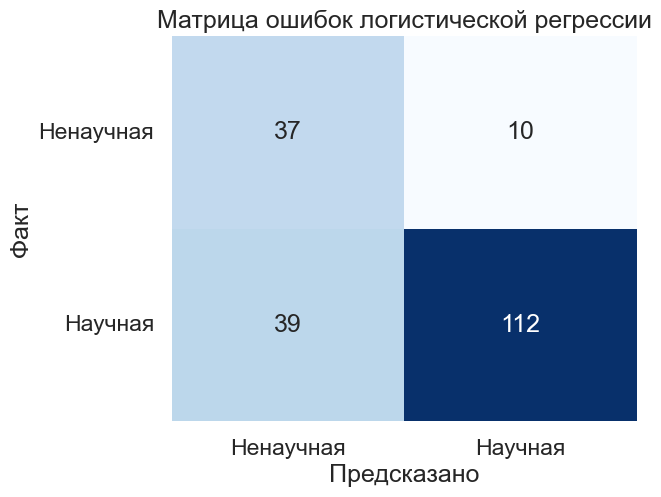

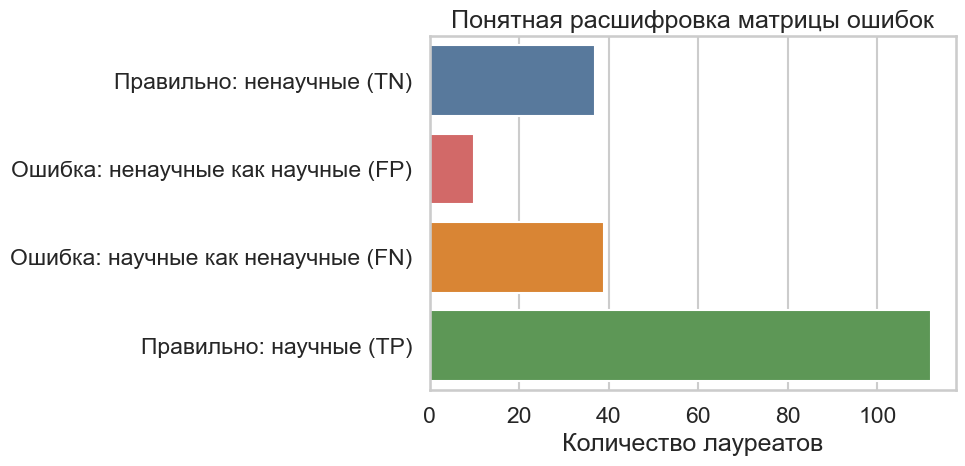

Пояснение:
- Синие/зеленые столбцы — правильные решения модели.
- Оранжевый/красный столбцы — ошибки модели.
- Чем больше правильных и меньше ошибочных столбцов, тем лучше классификатор.


In [25]:
reg_df = analysis_df.dropna(
    subset=[
        "age_awarded",
        "award_year_num",
        "prize_amount_log",
    ]
).copy()

reg_numeric_features = ["age_awarded", "award_year_num"]

reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), reg_numeric_features),
    ]
)

X_reg = reg_df[reg_numeric_features]
y_reg = reg_df["prize_amount_log"]
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_model = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor),
        ("model", LinearRegression()),
    ]
)

reg_model.fit(X_reg_train, y_reg_train)
y_reg_pred = reg_model.predict(X_reg_test)

regression_metrics = pd.Series(
    {
        "Коэффициент детерминации R²": r2_score(y_reg_test, y_reg_pred),
        "Средняя абсолютная ошибка": mean_absolute_error(y_reg_test, y_reg_pred),
        "Корень из средней квадратичной ошибки": np.sqrt(mean_squared_error(y_reg_test, y_reg_pred)),
    },
    name="Значение",
)

print("Множественная линейная регрессия: логарифм суммы премии от возраста и года лауреата")
display(regression_metrics.to_frame())

clf_df = analysis_df.dropna(
    subset=[
        "is_science",
        "age_awarded",
        "award_year_num",
        "prize_amount_log",
        "gender",
        "continent_group",
    ]
).copy()

clf_numeric_features = ["age_awarded", "award_year_num", "prize_amount_log", "prize_count"]
clf_categorical_features = ["gender", "continent_group"]

clf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), clf_numeric_features),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore"))]), clf_categorical_features),
    ]
)

X_clf = clf_df[clf_numeric_features + clf_categorical_features]
y_clf = clf_df["is_science"]
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf,
)

clf_model = Pipeline(
    steps=[
        ("preprocessor", clf_preprocessor),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
    ]
)

clf_model.fit(X_clf_train, y_clf_train)
y_clf_pred = clf_model.predict(X_clf_test)
y_clf_prob = clf_model.predict_proba(X_clf_test)[:, 1]

classification_metrics = pd.Series(
    {
        "Точность": accuracy_score(y_clf_test, y_clf_pred),
        "Точность положительного класса": precision_score(y_clf_test, y_clf_pred),
        "Полнота": recall_score(y_clf_test, y_clf_pred),
        "F1-мера": f1_score(y_clf_test, y_clf_pred),
        "ROC-AUC": roc_auc_score(y_clf_test, y_clf_prob),
    },
    name="Значение",
)

print("\nЛогистическая регрессия: классификация научных и ненаучных премий")
display(classification_metrics.to_frame())
print("\nОтчет по классификации")
report = classification_report(y_clf_test, y_clf_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T.rename(index={"0": "Ненаучные премии", "1": "Научные премии", "accuracy": "Точность", "macro avg": "Макроусреднение", "weighted avg": "Взвешенное среднее"})
report_df = report_df.rename(columns={"precision": "Точность", "recall": "Полнота", "f1-score": "F1-мера", "support": "Число объектов"})
display(report_df)

cm = confusion_matrix(y_clf_test, y_clf_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Матрица ошибок логистической регрессии")
plt.xlabel("Предсказано")
plt.ylabel("Факт")
plt.xticks([0.5, 1.5], ["Ненаучная", "Научная"])
plt.yticks([0.5, 1.5], ["Ненаучная", "Научная"], rotation=0)
plt.show()

# Поясняющая визуализация для обывателя: что означает каждая ячейка матрицы ошибок.
tn, fp, fn, tp = cm.ravel()
cm_human = pd.Series(
    {
        "Правильно: ненаучные (TN)": tn,
        "Ошибка: ненаучные как научные (FP)": fp,
        "Ошибка: научные как ненаучные (FN)": fn,
        "Правильно: научные (TP)": tp,
    }
)

plt.figure(figsize=(10, 5))
sns.barplot(x=cm_human.values, y=cm_human.index, palette=["#4C78A8", "#E45756", "#F58518", "#54A24B"])
plt.title("Понятная расшифровка матрицы ошибок")
plt.xlabel("Количество лауреатов")
plt.ylabel("")
plt.tight_layout()
plt.show()

print("Пояснение:")
print("- Синие/зеленые столбцы — правильные решения модели.")
print("- Оранжевый/красный столбцы — ошибки модели.")
print("- Чем больше правильных и меньше ошибочных столбцов, тем лучше классификатор.")

### V.1. Линейная регрессия

В этой главе отдельно рассматривается множественная линейная регрессия. Цель модели — предсказать возраст лауреата на момент получения премии по набору числовых и категориальных признаков.

График ниже показывает, насколько близко предсказанные значения лежат к фактическим. Если точки располагаются рядом с диагональю, модель работает точнее.


Простая линейная регрессия: год рождения лауреата по году премии


,Значение
Коэффициент детерминации R²,0.876877
Средняя абсолютная ошибка,9.317493
Корень из средней квадратичной ошибки,11.285854


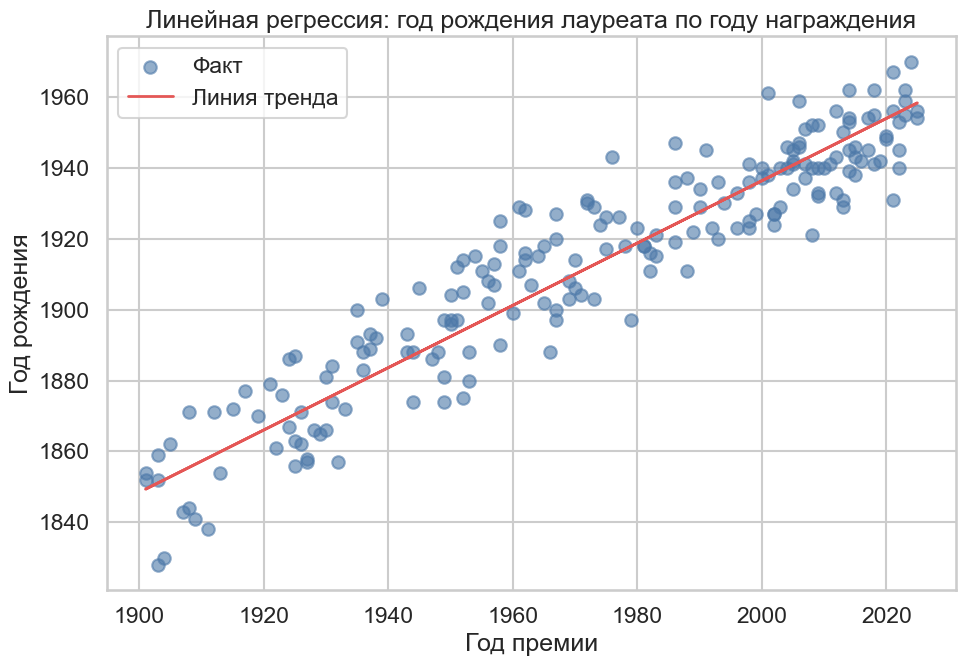

Пояснение:
- Синие точки показывают фактический год рождения лауреатов.
- Красная линия — предсказанная тенденция изменения года рождения со временем.
- Если линия хорошо описывает облако точек, модель работает хорошо.


In [26]:
# Простая линейная регрессия: год рождения по году награждения.
simple_linear_df = analysis_df.dropna(subset=["birth_year", "award_year_num"]).copy()

linear_X = simple_linear_df[["award_year_num"]]
linear_y = simple_linear_df["birth_year"]
linear_X_train, linear_X_test, linear_y_train, linear_y_test = train_test_split(linear_X, linear_y, test_size=0.2, random_state=42)

simple_linear_model = LinearRegression()
simple_linear_model.fit(linear_X_train, linear_y_train)
linear_y_pred = simple_linear_model.predict(linear_X_test)

linear_regression_metrics = pd.Series(
    {
        "Коэффициент детерминации R²": r2_score(linear_y_test, linear_y_pred),
        "Средняя абсолютная ошибка": mean_absolute_error(linear_y_test, linear_y_pred),
        "Корень из средней квадратичной ошибки": np.sqrt(mean_squared_error(linear_y_test, linear_y_pred)),
    },
    name="Значение",
)

print("Простая линейная регрессия: год рождения лауреата по году премии")
display(linear_regression_metrics.to_frame())

# График линейной регрессии: год рождения против года награждения с линией тренда.
plt.figure(figsize=(10, 7))
plt.scatter(linear_X_test["award_year_num"], linear_y_test, color="#4C78A8", alpha=0.6, label="Факт")
plt.plot(linear_X_test["award_year_num"], linear_y_pred, color="#E45756", linewidth=2, label="Линия тренда")
plt.title("Линейная регрессия: год рождения лауреата по году награждения")
plt.xlabel("Год премии")
plt.ylabel("Год рождения")
plt.legend()
plt.tight_layout()
plt.show()

print("Пояснение:")
print("- Синие точки показывают фактический год рождения лауреатов.")
print("- Красная линия — предсказанная тенденция изменения года рождения со временем.")
print("- Если линия хорошо описывает облако точек, модель работает хорошо.")

### V.2. Логистическая регрессия

В этой главе отдельно рассматривается логистическая регрессия. Модель отвечает на вопрос, является ли премия научной или ненаучной, и делает это на основе набора признаков о лауреате и премии.

График ниже показывает ROC-кривую: она помогает понять, насколько хорошо модель различает два класса.


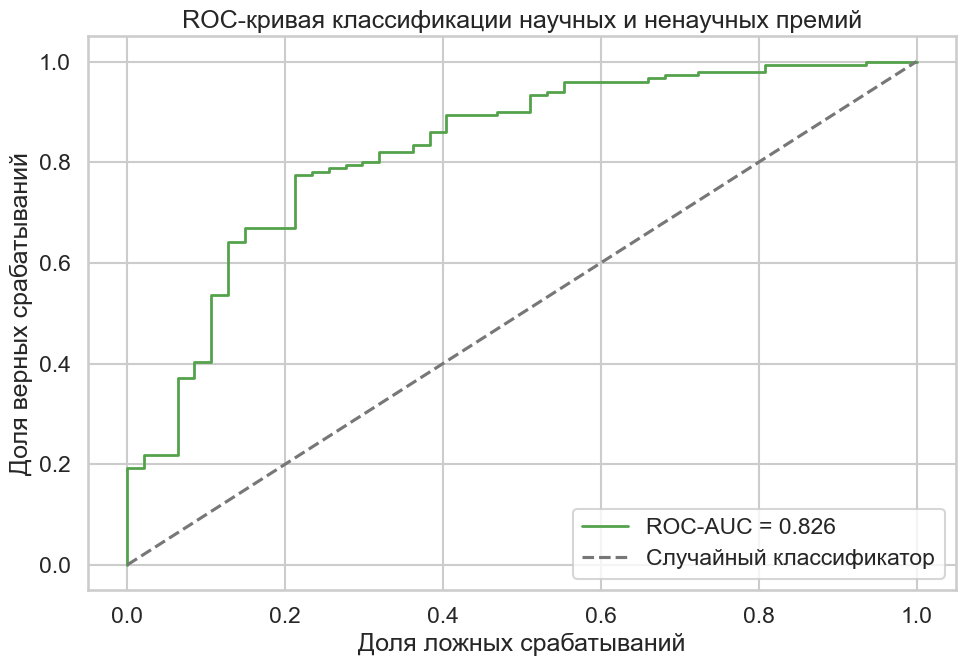

In [27]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_clf_test, y_clf_prob)

plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color="#54A24B", linewidth=2, label=f"ROC-AUC = {roc_auc_score(y_clf_test, y_clf_prob):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="#777777", label="Случайный классификатор")
plt.title("ROC-кривая классификации научных и ненаучных премий")
plt.xlabel("Доля ложных срабатываний")
plt.ylabel("Доля верных срабатываний")
plt.legend()
plt.tight_layout()
plt.show()

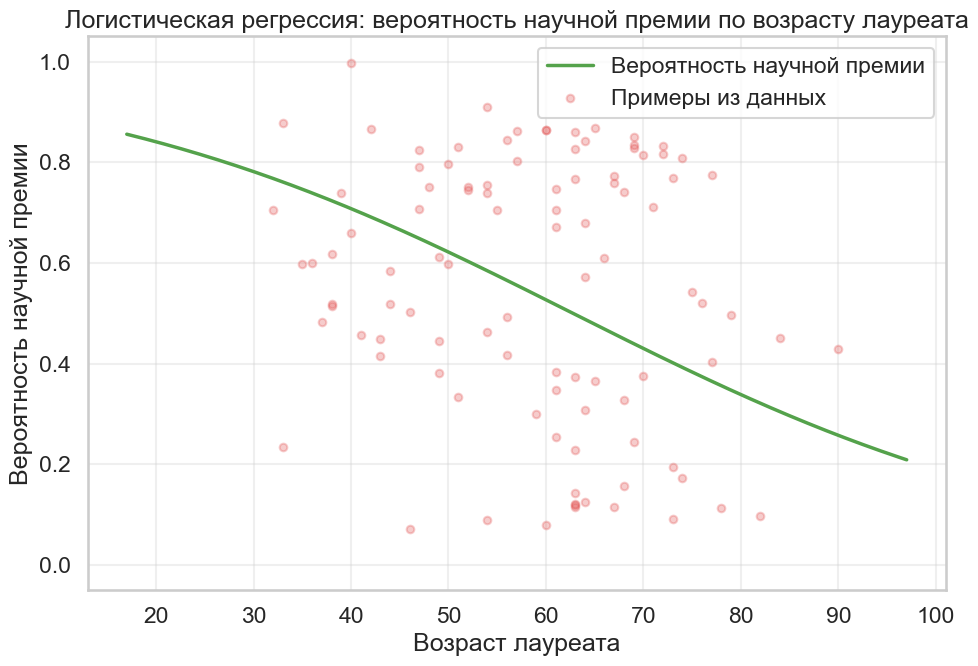

Пояснение сигмоидной кривой логистической регрессии:
- Кривая показывает вероятность того, что награда является научной.
- S-образная форма кривой характерна для логистической функции.
- Вероятность растет с возрастом, показывая, что более опытные ученые более вероятно получают научные премии.
- Точки отвлняются от кривой, потому что это реальные данные с шумом и другими факторами.


In [28]:
# Визуализация логистической регрессии: сигмоидная кривая вероятности.
# Рассчитаем вероятность того, что премия является научной в зависимости от возраста лауреата.
from scipy.special import expit

# Получим коэффициенты модели для возраста после масштабирования
clf_feature_names = (clf_model.named_steps["preprocessor"].get_feature_names_out())
age_index = list(clf_feature_names).index("num__age_awarded")

# Создадим диапазон возрастов
age_range = np.linspace(clf_df["age_awarded"].min(), clf_df["age_awarded"].max(), 300)

# Подготовим данные для предсказания (используем только возраст, остальные признаки заполнены средими)
predict_data = pd.DataFrame({
    "age_awarded": age_range,
    "award_year_num": [clf_df["award_year_num"].mean()] * len(age_range),
    "prize_amount_log": [clf_df["prize_amount_log"].mean()] * len(age_range),
    "prize_count": [clf_df["prize_count"].mean()] * len(age_range),
    "gender": [clf_df["gender"].mode()[0]] * len(age_range),
    "continent_group": [clf_df["continent_group"].mode()[0]] * len(age_range),
})

# Предсказываем вероятности
probabilities = clf_model.predict_proba(predict_data)[:, 1]

# График сигмоидной кривой
plt.figure(figsize=(10, 7))
plt.plot(age_range, probabilities, color="#54A24B", linewidth=2.5, label="Вероятность научной премии")

# Добавим реальные точки (с некоторым шумом для визуализации)
sample_data = clf_df.sample(min(100, len(clf_df)), random_state=42)
sample_predict = clf_model.predict_proba(sample_data[["age_awarded", "award_year_num", "prize_amount_log", "prize_count", "gender", "continent_group"]])[:, 1]
plt.scatter(sample_data["age_awarded"], sample_predict, alpha=0.3, s=30, color="#E45756", label="Примеры из данных")

plt.title("Логистическая регрессия: вероятность научной премии по возрасту лауреата")
plt.xlabel("Возраст лауреата")
plt.ylabel("Вероятность научной премии")
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Пояснение сигмоидной кривой логистической регрессии:")
print("- Кривая показывает вероятность того, что награда является научной.") 
print("- S-образная форма кривой характерна для логистической функции.")
print("- Вероятность растет с возрастом, показывая, что более опытные ученые более вероятно получают научные премии.")
print("- Точки отвлняются от кривой, потому что это реальные данные с шумом и другими факторами.")

### V.1. Непосредственная визуализация моделей

Ниже показаны графики, которые помогают увидеть работу моделей не только по числам, но и визуально:

- для множественной линейной регрессии показываем облако точек в 3D-пространстве;
- для логистической регрессии оставляем метрики и матрицу ошибок без отдельного дополнительного графика;
- это делает выводы о моделях понятными не только по метрикам, но и по форме самих предсказаний.

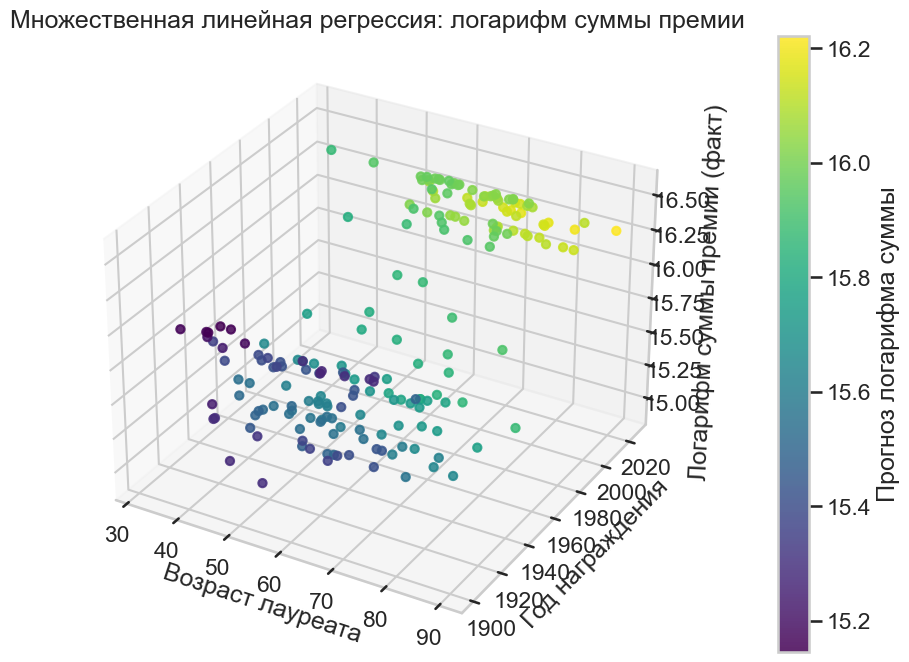

Пояснение к регрессии:
- Каждая точка — отдельный лауреат из тестовой выборки.
- Три оси: возраст, год награждения и фактический логарифм суммы премии.
- Цвет отражает предсказанный логарифм суммы премии моделью.
- Если цвета согласованы с положением по Z (фактические значения), модель работает хорошо.


In [29]:
# Множественная линейная регрессия: 3D-облако точек в пространстве признаков.
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

regression_results = pd.DataFrame({
    "Возраст лауреата": X_reg_test["age_awarded"].values,
    "Год награждения": X_reg_test["award_year_num"].values,
    "Фактический логарифм суммы": y_reg_test.values,
    "Прогноз логарифма суммы": y_reg_pred,
})

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(
    regression_results["Возраст лауреата"],
    regression_results["Год награждения"],
    regression_results["Фактический логарифм суммы"],
    c=regression_results["Прогноз логарифма суммы"],
    cmap="viridis",
    alpha=0.85,
    s=35,
)
ax.set_title("Множественная линейная регрессия: логарифм суммы премии")
ax.set_xlabel("Возраст лауреата")
ax.set_ylabel("Год награждения")
ax.set_zlabel("Логарифм суммы премии (факт)")
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label("Прогноз логарифма суммы")
plt.show()

print("Пояснение к регрессии:")
print("- Каждая точка — отдельный лауреат из тестовой выборки.")
print("- Три оси: возраст, год награждения и фактический логарифм суммы премии.")
print("- Цвет отражает предсказанный логарифм суммы премии моделью.")
print("- Если цвета согласованы с положением по Z (фактические значения), модель работает хорошо.")

Анализ главных компонент: доля объясненной дисперсии


,Доля объясненной дисперсии
Первая компонента,0.477533
Вторая компонента,0.214254


Суммарно первые две компоненты объясняют 0.692 дисперсии


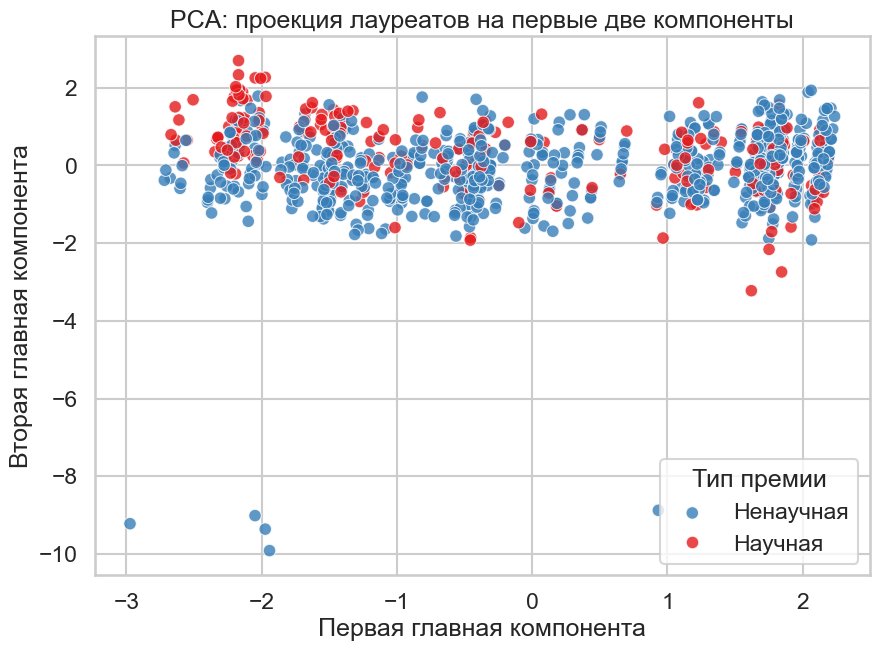

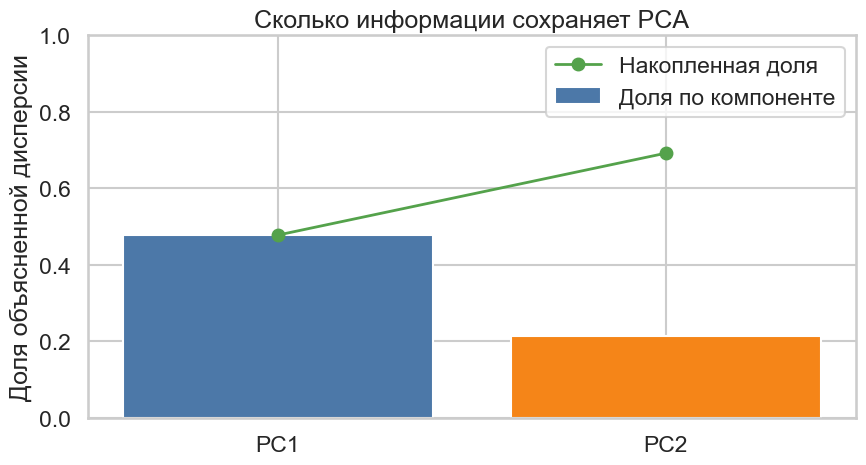

Пояснение по PCA простыми словами:
- PCA сжимает много признаков в несколько осей с минимальной потерей информации.
- PC1 — самая информативная ось, PC2 — следующая по важности.
- Накопленная линия показывает, сколько общей информации уже сохранено.
Лучшая модель ARIMA: порядок (2, 1, 2), AIC = 461.76
Оценка ARIMA на последних 10 годах


,Значение
Средняя абсолютная ошибка,1.183185
Корень из средней квадратичной ошибки,1.437700


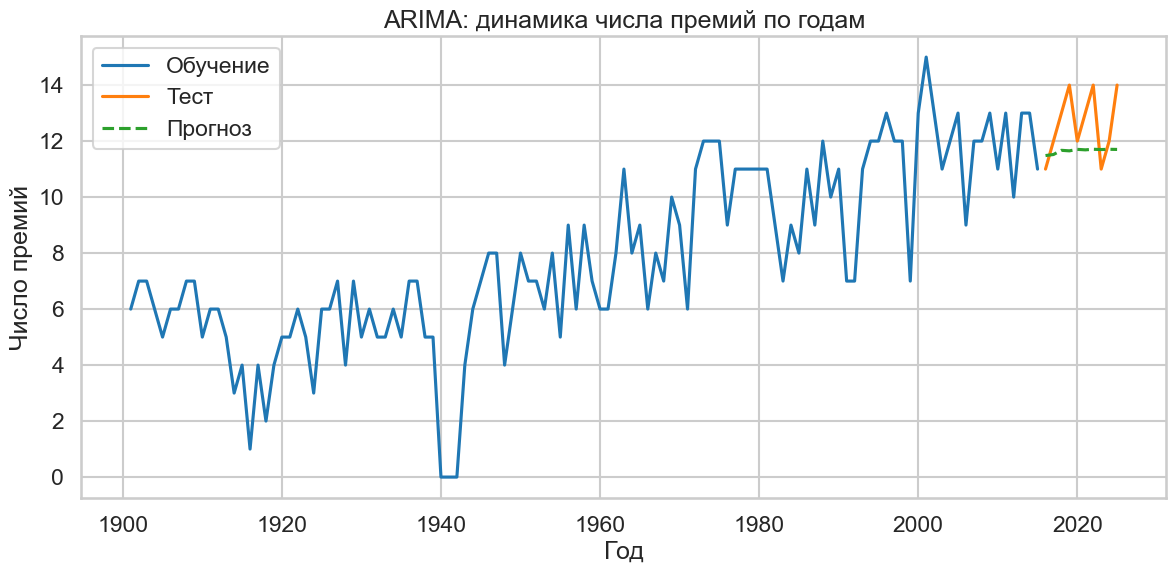

Пояснение по ARIMA простыми словами:
- ARIMA — модель, которая учится на прошлых значениях временного ряда и прогнозирует будущие.
- Обучение (синяя линия): историческая часть ряда, на которой модель настраивается.
- Тест (оранжевая линия): реальные значения, которые модель не видела при обучении.
- Прогноз (зеленая пунктирная линия): предсказания модели на тестовом отрезке.
- Чем ближе прогноз к тесту, тем лучше модель улавливает динамику ряда.
Прогноз на следующие 5 лет


,Год,Предсказанное число премий
0,2026,11.482820
1,2027,11.520403
2,2028,11.670081
3,2029,11.651329
4,2030,11.704029


In [30]:
pca_df = analysis_df.dropna(
    subset=["birth_year", "award_year_num", "age_awarded", "prize_amount_log", "prize_count", "is_science"]
).copy()

pca_features = ["birth_year", "award_year_num", "age_awarded", "prize_amount_log", "prize_count"]
X_pca = pca_df[pca_features]
X_pca_scaled = StandardScaler().fit_transform(X_pca)

pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_pca_scaled)
pca_df["pc1"] = pca_components[:, 0]
pca_df["pc2"] = pca_components[:, 1]

print("Анализ главных компонент: доля объясненной дисперсии")
display(pd.Series(pca.explained_variance_ratio_, index=["Первая компонента", "Вторая компонента"], name="Доля объясненной дисперсии").to_frame())
print(f"Суммарно первые две компоненты объясняют {pca.explained_variance_ratio_.sum():.3f} дисперсии")

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x="pc1", y="pc2", hue="is_science", palette="Set1", alpha=0.8)
plt.title("PCA: проекция лауреатов на первые две компоненты")
plt.xlabel("Первая главная компонента")
plt.ylabel("Вторая главная компонента")
plt.legend(title="Тип премии", labels=["Ненаучная", "Научная"])
plt.show()

# Дополнительная визуализация PCA для обывателя: сколько информации сохраняют компоненты.
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(9, 5))
plt.bar(["PC1", "PC2"], explained, color=["#4C78A8", "#F58518"], label="Доля по компоненте")
plt.plot(["PC1", "PC2"], cumulative, marker="o", color="#54A24B", linewidth=2, label="Накопленная доля")
plt.title("Сколько информации сохраняет PCA")
plt.ylabel("Доля объясненной дисперсии")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

print("Пояснение по PCA простыми словами:")
print("- PCA сжимает много признаков в несколько осей с минимальной потерей информации.")
print("- PC1 — самая информативная ось, PC2 — следующая по важности.")
print("- Накопленная линия показывает, сколько общей информации уже сохранено.")

# Анализ временного ряда: число присужденных премий по годам.
yearly_series = prize_df.copy()
yearly_series["award_year"] = pd.to_numeric(yearly_series["award_year"], errors="coerce")
yearly_series = yearly_series.dropna(subset=["award_year"])
yearly_counts = yearly_series.groupby("award_year").size().sort_index()
full_years = pd.Index(range(int(yearly_counts.index.min()), int(yearly_counts.index.max()) + 1), name="award_year")
yearly_counts = yearly_counts.reindex(full_years, fill_value=0).astype(float)

forecast_horizon = 10
train_series = yearly_counts.iloc[:-forecast_horizon]
test_series = yearly_counts.iloc[-forecast_horizon:]

best_order = None
best_aic = np.inf
best_model = None

for p in range(0, 3):
    for d in range(0, 2):
        for q in range(0, 3):
            try:
                candidate = ARIMA(
                    train_series,
                    order=(p, d, q),
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                ).fit()
                if candidate.aic < best_aic:
                    best_aic = candidate.aic
                    best_order = (p, d, q)
                    best_model = candidate
            except Exception:
                continue

if best_model is None:
    best_order = (1, 1, 1)
    best_model = ARIMA(
        train_series,
        order=best_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit()
    best_aic = best_model.aic

print(f"Лучшая модель ARIMA: порядок {best_order}, AIC = {best_aic:.2f}")

test_forecast = best_model.forecast(steps=forecast_horizon)
forecast_metrics = pd.Series(
    {
        "Средняя абсолютная ошибка": mean_absolute_error(test_series, test_forecast),
        "Корень из средней квадратичной ошибки": np.sqrt(mean_squared_error(test_series, test_forecast)),
    },
    name="Значение",
)
print("Оценка ARIMA на последних 10 годах")
display(forecast_metrics.to_frame())

plt.figure(figsize=(14, 6))
plt.plot(train_series.index, train_series.values, label="Обучение", color="#1f77b4")
plt.plot(test_series.index, test_series.values, label="Тест", color="#ff7f0e")
plt.plot(test_series.index, test_forecast.values, label="Прогноз", color="#2ca02c", linestyle="--")
plt.title("ARIMA: динамика числа премий по годам")
plt.xlabel("Год")
plt.ylabel("Число премий")
plt.legend()
plt.show()

print("Пояснение по ARIMA простыми словами:")
print("- ARIMA — модель, которая учится на прошлых значениях временного ряда и прогнозирует будущие.")
print("- Обучение (синяя линия): историческая часть ряда, на которой модель настраивается.")
print("- Тест (оранжевая линия): реальные значения, которые модель не видела при обучении.")
print("- Прогноз (зеленая пунктирная линия): предсказания модели на тестовом отрезке.")
print("- Чем ближе прогноз к тесту, тем лучше модель улавливает динамику ряда.")

future_steps = 5
future_forecast = best_model.forecast(steps=future_steps)
print("Прогноз на следующие 5 лет")
display(pd.DataFrame({"Год": range(int(yearly_counts.index.max()) + 1, int(yearly_counts.index.max()) + 1 + future_steps), "Предсказанное число премий": future_forecast.values}))

### VI. Дополнительный анализ: типы премий и пол внутри категорий

Этот блок нужен, чтобы увидеть не только общую структуру данных, но и различия между категориями внутри пола. Здесь мы сравниваем количество мужчин и женщин в каждой категории и дополнительно смотрим долю женщин внутри категорий.

Главный вопрос: в каких категориях женское представительство выше, а где сохраняется сильный дисбаланс в пользу мужчин?

Сравнение пола внутри категорий


gender,Мужчины,Женщины,Всего,Доля женщин
first_category,,,,
Физиология или медицина,218,14,232,0.060345
Физика,224,5,229,0.021834
Химия,190,7,197,0.035533
Литература,104,18,122,0.147541
Премия мира,91,20,111,0.180180
Экономические науки,96,3,99,0.030303


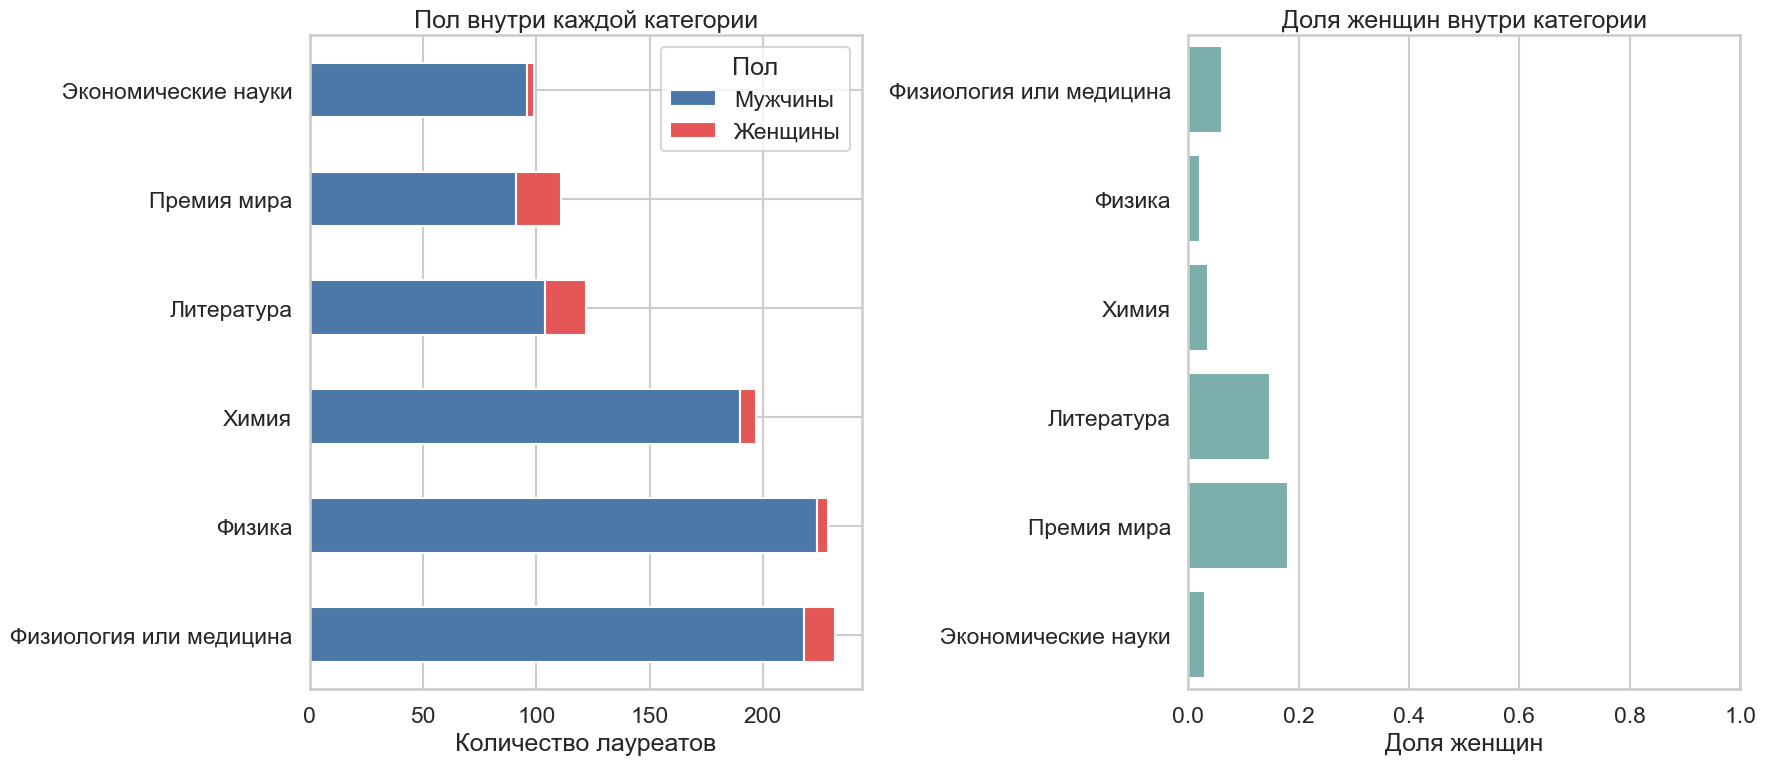


Выводы по дополнительному анализу:
- В гуманитарных и миротворческих категориях доля женщин заметно выше, чем в научных.
- В физике, химии и экономических науках сохраняется сильное доминирование мужчин.
- Анализ внутри категорий дополняет общий график по полу и показывает, что дисбаланс неодинаков в разных типах премий.


In [31]:
category_gender = analysis_df.dropna(subset=["first_category", "gender"]).copy()
category_gender_counts = pd.crosstab(category_gender["first_category"], category_gender["gender"])
category_gender_counts = category_gender_counts.reindex(columns=["male", "female"], fill_value=0)
category_gender_counts["total"] = category_gender_counts.sum(axis=1)
category_gender_counts["female_share"] = category_gender_counts["female"] / category_gender_counts["total"]
category_gender_counts = category_gender_counts.sort_values("total", ascending=False)

category_gender_counts_ru = category_gender_counts.copy()
category_gender_counts_ru.index = category_gender_counts_ru.index.map(category_ru)
category_gender_counts_ru = category_gender_counts_ru.rename(columns={"male": "Мужчины", "female": "Женщины", "total": "Всего", "female_share": "Доля женщин"})

print("Сравнение пола внутри категорий")
display(category_gender_counts_ru)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

plot_df = category_gender_counts[["male", "female"]].copy()
plot_df.index = plot_df.index.map(category_ru)
plot_df = plot_df.rename(columns={"male": "Мужчины", "female": "Женщины"})
plot_df[["Мужчины", "Женщины"]].plot(kind="barh", stacked=True, ax=axes[0], color=["#4C78A8", "#E45756"])
axes[0].set_title("Пол внутри каждой категории")
axes[0].set_xlabel("Количество лауреатов")
axes[0].set_ylabel("")
axes[0].legend(title="Пол")

share_df = category_gender_counts[["female_share"]].copy()
share_df.index = share_df.index.map(category_ru)
sns.barplot(x=share_df["female_share"].values, y=share_df.index, ax=axes[1], color="#72B7B2")
axes[1].set_title("Доля женщин внутри категории")
axes[1].set_xlabel("Доля женщин")
axes[1].set_ylabel("")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

print("\nВыводы по дополнительному анализу:")
print("- В гуманитарных и миротворческих категориях доля женщин заметно выше, чем в научных.")
print("- В физике, химии и экономических науках сохраняется сильное доминирование мужчин.")
print("- Анализ внутри категорий дополняет общий график по полу и показывает, что дисбаланс неодинаков в разных типах премий.")

### VII. Интерпретация результатов, выводы и ограничения

**Ключевые наблюдения:**

- распределение лауреатов по категориям сильно неравномерно, при этом научные категории доминируют;
- женщины представлены существенно реже мужчин, что видно и на уровне общего распределения, и в разрезе категорий;
- дополнительный анализ показал, что внутри категорий доля женщин выше в гуманитарных и миротворческих премиях, а в физических, химических и экономических науках сохраняется сильное преобладание мужчин;
- возраст на момент награждения варьируется заметно, а наиболее зрелые лауреаты обычно встречаются в литературе и премии мира;
- временной ряд числа присужденных премий по годам имеет выраженную динамику, поэтому ARIMA применима к агрегированному годовому счётчику;
- PCA показывает, что часть вариации хорошо объясняется несколькими числовыми признаками, но полная структура данных остаётся многомерной.

**Ограничения анализа:**

- часть записей содержит пропуски в биографических и аффилиационных полях;
- классификационная задача построена на производном признаке `is_science`, поэтому она иллюстрирует методологию, а не самостоятельную предметную задачу;
- ARIMA применена к агрегированному годовому ряду, а не к индивидуальным лауреатам;
- исторические изменения правил присуждения премий и инфляция делают прямое сравнение денежных сумм ограниченно интерпретируемым.

### VIII. Библиография и вклад участников

**Источники данных и методические материалы:**

- Nobel Prize API: `https://api.nobelprize.org/2.1/laureates`
- `reference/Lucrare individuală de grup 2.pdf`
- `reference/C8-C11 MSAD.pdf`
- документация `pandas`, `matplotlib`, `seaborn`, `scikit-learn`, `statsmodels`

**Вклад членов команды:**

- Григорий Зайка — постановка темы, загрузка данных, очистка и построение признаков.
- Артур Мамалига — EDA, визуализации и интерпретация распределений.
- Анатолий Курилов — регрессия, классификация, PCA, ARIMA и сводные выводы.

**Примечание:** код и визуализации в ноутбуке рассчитаны на воспроизводимый запуск в Jupyter Notebook и соответствуют структуре разделов I–VIII из задания.